In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("india_flood_curated_2000_2026.csv")

In [3]:
df.head()

,Event_ID,Year,Month,State,District,Flood_Type,River_Name,Rainfall_mm,Rainfall_Category,River_Water_Level_m,...,Population_Density,Previous_Flood_History,Main_Cause,People_Affected,Deaths,Missing_Persons,Injured,Houses_Damaged,Crop_Loss_Hectares,Severity
0,FLD0001,2000,7,Assam,Dhemaji,River Flood,Brahmaputra,280,Heavy,9.8,...,480,Yes,River Overflow,150000,35,5,60,9000,4500,High
1,FLD0002,2000,7,Assam,Barpeta,River Flood,Brahmaputra,260,Heavy,9.5,...,620,Yes,Heavy Monsoon Rainfall,150000,35,5,60,9000,4500,High
2,FLD0003,2000,8,Bihar,Purnia,River Flood,Kosi,270,Heavy,7.2,...,1250,Yes,River Overflow,150000,35,5,60,9000,4500,High
3,FLD0004,2000,8,Bihar,Darbhanga,River Flood,Bagmati,250,Heavy,6.8,...,1600,Yes,Heavy Monsoon Rainfall,45000,8,1,15,3000,1200,Medium
4,FLD0005,2000,8,West Bengal,Malda,River Flood,Ganga,240,Heavy,8.1,...,1100,Yes,River Overflow,45000,8,1,15,3000,1200,Medium


In [4]:
df.tail()

,Event_ID,Year,Month,State,District,Flood_Type,River_Name,Rainfall_mm,Rainfall_Category,River_Water_Level_m,...,Population_Density,Previous_Flood_History,Main_Cause,People_Affected,Deaths,Missing_Persons,Injured,Houses_Damaged,Crop_Loss_Hectares,Severity
110,FLD0111,2026,7,Assam,Sivasagar,River Flood,Disang,310,Extreme,10.3,...,520,Yes,River Overflow,380000,22,2,65,11000,8500,Extreme
111,FLD0112,2026,7,Assam,Charaideo,River Flood,Brahmaputra,300,Extreme,10.1,...,480,Yes,River Overflow,290000,19,1,50,8500,6500,Extreme
112,FLD0113,2026,7,Assam,Dibrugarh,River Flood,Brahmaputra,295,Heavy,9.9,...,450,Yes,Heavy Monsoon Rainfall,310000,21,2,55,9200,7000,Extreme
113,FLD0114,2026,7,Assam,Golaghat,River Flood,Dhansiri,280,Heavy,9.5,...,470,Yes,Heavy Monsoon Rainfall,180000,12,1,35,5500,4200,High
114,FLD0115,2026,7,Assam,Lakhimpur,River Flood,Brahmaputra,290,Heavy,9.8,...,500,Yes,River Overflow,210000,8,1,30,6200,4800,Extreme


In [5]:
df.shape

(115, 25)

In [6]:
df.isnull().sum()

Event_ID                  0
Year                      0
Month                     0
State                     0
District                  0
Flood_Type                0
River_Name                0
Rainfall_mm               0
Rainfall_Category         0
River_Water_Level_m       0
Dam_Release               0
Temperature_C             0
Soil_Type                 0
Elevation_m               0
Land_Use                  0
Population_Density        0
Previous_Flood_History    0
Main_Cause                0
People_Affected           0
Deaths                    0
Missing_Persons           0
Injured                   0
Houses_Damaged            0
Crop_Loss_Hectares        0
Severity                  0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event_ID                115 non-null    str    
 1   Year                    115 non-null    int64  
 2   Month                   115 non-null    int64  
 3   State                   115 non-null    str    
 4   District                115 non-null    str    
 5   Flood_Type              115 non-null    str    
 6   River_Name              115 non-null    str    
 7   Rainfall_mm             115 non-null    int64  
 8   Rainfall_Category       115 non-null    str    
 9   River_Water_Level_m     115 non-null    float64
 10  Dam_Release             115 non-null    str    
 11  Temperature_C           115 non-null    int64  
 12  Soil_Type               115 non-null    str    
 13  Elevation_m             115 non-null    int64  
 14  Land_Use                115 non-null    str    
 15  

In [10]:
month_names = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

df["Month"] = df["Month"].map(month_names)

In [11]:
df.head()

,Event_ID,Year,Month,State,District,Flood_Type,River_Name,Rainfall_mm,Rainfall_Category,River_Water_Level_m,...,Population_Density,Previous_Flood_History,Main_Cause,People_Affected,Deaths,Missing_Persons,Injured,Houses_Damaged,Crop_Loss_Hectares,Severity
0,FLD0001,2000,July,Assam,Dhemaji,River Flood,Brahmaputra,280,Heavy,9.8,...,480,Yes,River Overflow,150000,35,5,60,9000,4500,High
1,FLD0002,2000,July,Assam,Barpeta,River Flood,Brahmaputra,260,Heavy,9.5,...,620,Yes,Heavy Monsoon Rainfall,150000,35,5,60,9000,4500,High
2,FLD0003,2000,August,Bihar,Purnia,River Flood,Kosi,270,Heavy,7.2,...,1250,Yes,River Overflow,150000,35,5,60,9000,4500,High
3,FLD0004,2000,August,Bihar,Darbhanga,River Flood,Bagmati,250,Heavy,6.8,...,1600,Yes,Heavy Monsoon Rainfall,45000,8,1,15,3000,1200,Medium
4,FLD0005,2000,August,West Bengal,Malda,River Flood,Ganga,240,Heavy,8.1,...,1100,Yes,River Overflow,45000,8,1,15,3000,1200,Medium


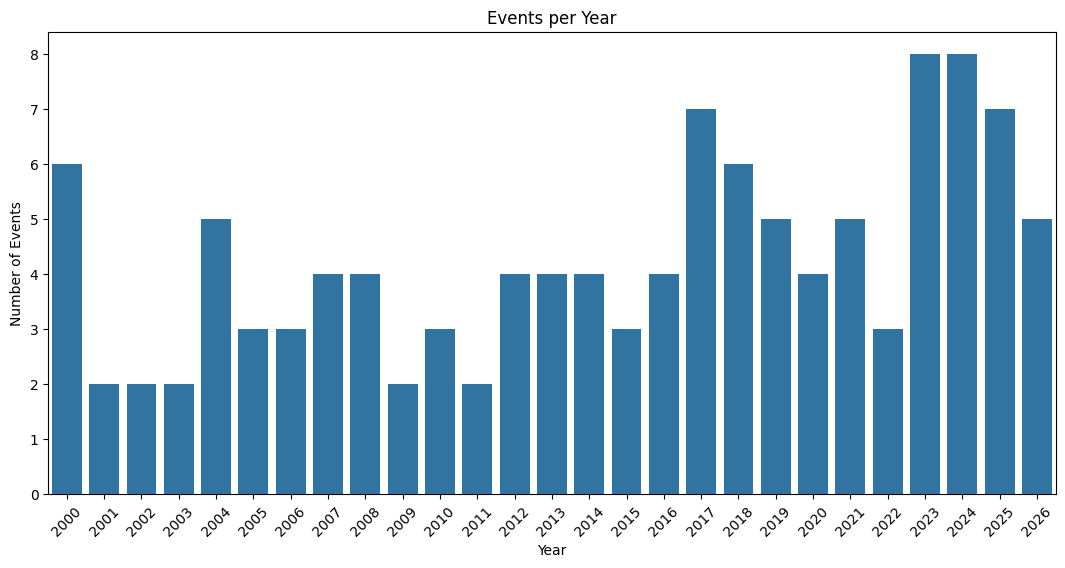

In [53]:
yearly_events = df["Year"].value_counts().sort_index()
plt.figure(figsize=(13,6))
sns.barplot(x=yearly_events.index,y=yearly_events.values)
plt.xticks(rotation=45)
plt.ylabel("Number of Events")
plt.title("Events per Year")
plt.show()

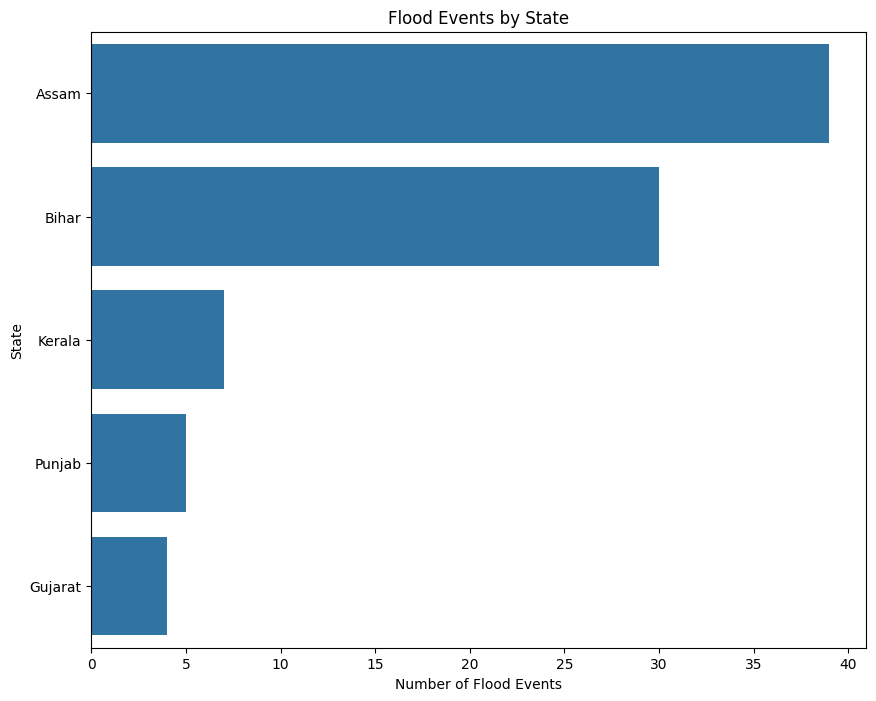

In [19]:
state_counts = df["State"].value_counts().head(5)

plt.figure(figsize=(10, 8))

sns.barplot(
    y=state_counts.index,
    x=state_counts.values
)

plt.title("Flood Events by State")
plt.xlabel("Number of Flood Events")
plt.ylabel("State")

plt.show()

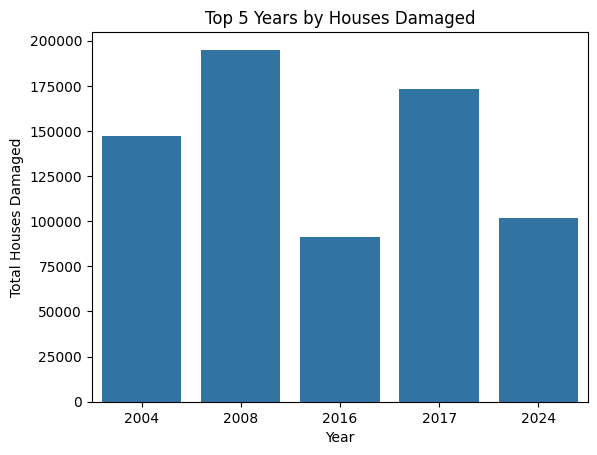

In [47]:
damage=df.groupby('Year')['Houses_Damaged'].sum().sort_values(ascending=False).head()
sns.barplot(x=damage.index,y=damage.values)
plt.title("Top 5 Years by Houses Damaged")
plt.xlabel("Year")
plt.ylabel("Total Houses Damaged")
plt.show()

In [54]:
df.head()

,Event_ID,Year,Month,State,District,Flood_Type,River_Name,Rainfall_mm,Rainfall_Category,River_Water_Level_m,...,Population_Density,Previous_Flood_History,Main_Cause,People_Affected,Deaths,Missing_Persons,Injured,Houses_Damaged,Crop_Loss_Hectares,Severity
0,FLD0001,2000,July,Assam,Dhemaji,River Flood,Brahmaputra,280,Heavy,9.8,...,480,Yes,River Overflow,150000,35,5,60,9000,4500,High
1,FLD0002,2000,July,Assam,Barpeta,River Flood,Brahmaputra,260,Heavy,9.5,...,620,Yes,Heavy Monsoon Rainfall,150000,35,5,60,9000,4500,High
2,FLD0003,2000,August,Bihar,Purnia,River Flood,Kosi,270,Heavy,7.2,...,1250,Yes,River Overflow,150000,35,5,60,9000,4500,High
3,FLD0004,2000,August,Bihar,Darbhanga,River Flood,Bagmati,250,Heavy,6.8,...,1600,Yes,Heavy Monsoon Rainfall,45000,8,1,15,3000,1200,Medium
4,FLD0005,2000,August,West Bengal,Malda,River Flood,Ganga,240,Heavy,8.1,...,1100,Yes,River Overflow,45000,8,1,15,3000,1200,Medium


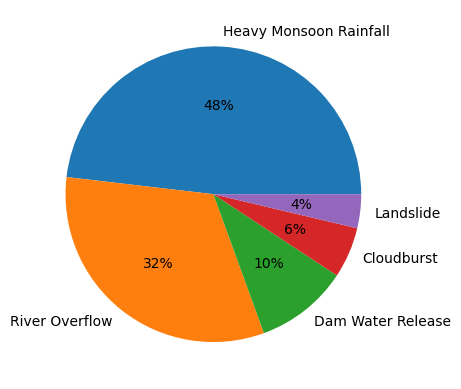

In [62]:
a=df['Main_Cause'].value_counts().head()
plt.pie(a.values,labels=a.index,autopct="%1.f%%")
plt.show()

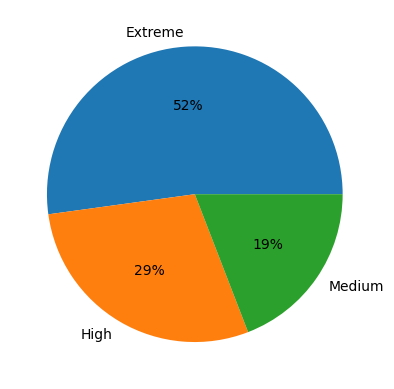

In [72]:
a=df['Severity'].value_counts()

plt.pie(a.values,labels=a.index,autopct='%1.f%%')
plt.show()

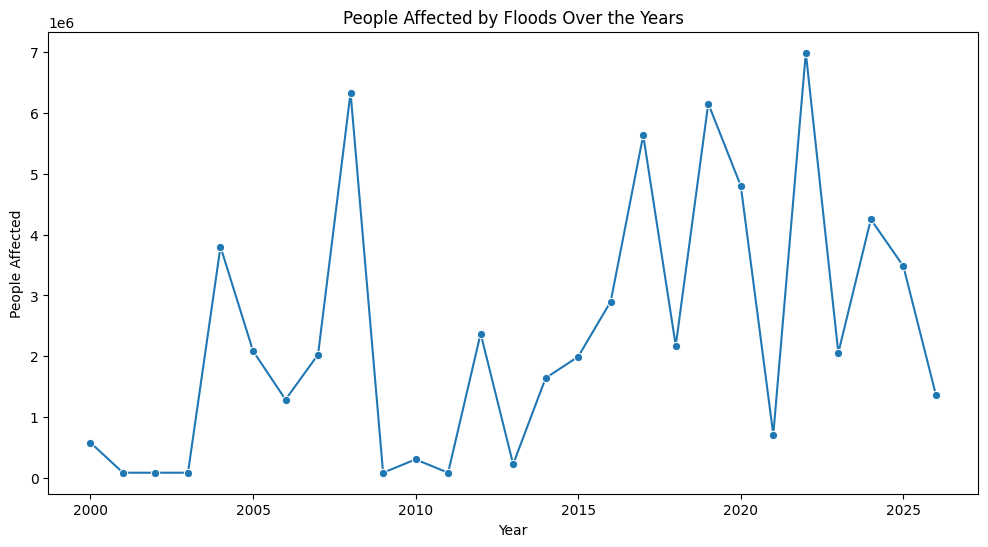

In [ ]:
affected = (
    df.groupby("Year")["People_Affected"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(12,6))
sns.lineplot(x=affected.index, y=affected.values, marker="o")
plt.title("People Affected by Floods Over the Years")
plt.xlabel("Year")
plt.ylabel("People Affected")

plt.show()

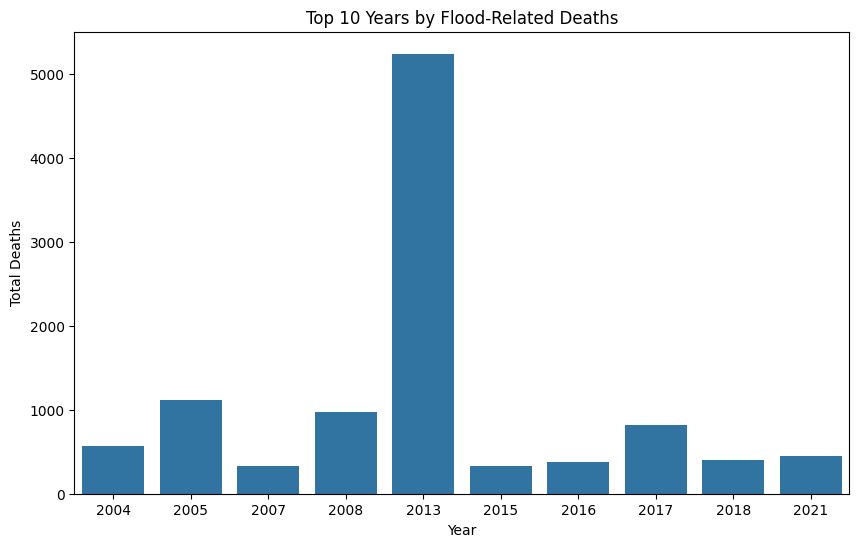

In [87]:
year_deaths = (
    df.groupby("Year")["Deaths"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=year_deaths.index,
    y=year_deaths.values
)

plt.title("Top 10 Years by Flood-Related Deaths")
plt.xlabel("Year")
plt.ylabel("Total Deaths")

plt.show()

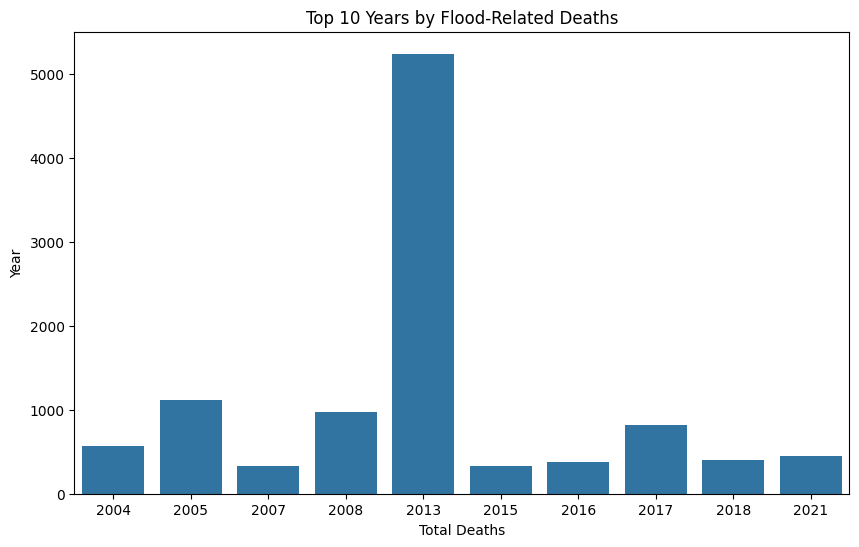

In [ ]:
year_deaths=(df.groupby("Year")["Deaths"].sum().sort_values(ascending=False).head(10))

plt.figure(figsize=(10, 6))

sns.barplot(x=year_deaths.index,y=year_deaths.values)
plt.title("Top 10 Years by Flood-Related Deaths")
plt.xlabel("Total Deaths")
plt.ylabel("Year")
plt.show()

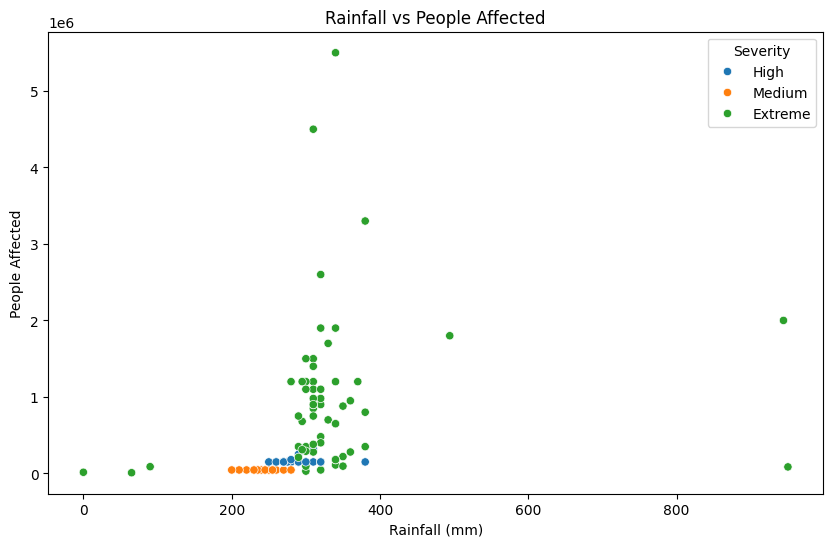

In [83]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="People_Affected",
    hue="Severity"
)

plt.title("Rainfall vs People Affected")
plt.xlabel("Rainfall (mm)")
plt.ylabel("People Affected")

plt.show()